# Session 6 - Model Interpretation and the Professional Use of AI

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at Abali  
**Session length:** 90 minutes  
**Data source (the only one used):** `data/raw/abali.xlsx`

---

## Learning objectives

**Part A - interpreting the model**

1. Compute and read **impurity-based feature importance**, and state its two main biases.
2. Compute **permutation importance** on held-out data and explain how it differs from the impurity version.
3. Explain a single prediction with **SHAP** (optional) or, when SHAP is unavailable, with a model-agnostic **partial-dependence** curve.
4. Analyse **residuals**: distribution, heteroscedasticity, autocorrelation, and what each pattern would mean physically.
5. Find the **diurnal cycle of error** and interpret it with boundary-layer physics.
6. Break the error down by **wind regime** and by **season**, and explain why the average error hides the story.

**Part B - working with LLMs like a professional**

7. Write prompts that produce usable scientific code, and prompts that produce a *critique* instead.
8. Verify AI-generated code and results with a repeatable set of checks.
9. Detect the four failure modes of AI answers: invented APIs, leakage, plausible-but-wrong statistics, and confidently wrong physical claims.
10. Draw the line between assistance and blind copying, and document AI use in a report.

## Prerequisites

Sessions 1-5.

---

## 1. Setup

We rebuild the dataset in memory and fit the two model families we will interpret: a random forest and a boosted ensemble. Interpretation always applies to **a specific fitted model**, so we keep the fitted objects in memory here (and free the ones we no longer need).

In [1]:
# ---------------------------------------------------------------------------
# Session 6 setup (self-contained)
# ---------------------------------------------------------------------------
import os
import sys
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

QUICK_MODE = True
N_TREES = 100 if QUICK_MODE else 300
N_JOBS = 2
HORIZONS = [3, 6, 12, 24]
H_MAIN = 6          # the horizon analysed in detail in this session

HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
    SHAP_VERSION = shap.__version__
except Exception as exc:
    SHAP_VERSION = 'not installed'
    print('[optional] shap not available:', exc)
    print('           install with:  pip install shap')
    print('           the notebook continues with partial-dependence curves instead')

HAS_LGBM = False
try:
    import lightgbm
    HAS_LGBM = True
except Exception as exc:
    print('[optional] lightgbm not available:', exc)

HAS_XGB = False
try:
    import xgboost
    HAS_XGB = True
except Exception as exc:
    print('[optional] xgboost not available:', exc)

RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError('Could not find abali.xlsx. Expected at ' + candidates[0] +
                            ' relative to the repository root.')


RAW_PATH = resolve_raw_path()
COL_MAP = {'DateTimes': 'datetime', 'Wind Speed(m/s)': 'wind_speed_ms',
           'Wind Direction(D)': 'wind_direction_deg', 'Air Pressure(hPa)': 'pressure_hpa',
           'Air Temperature(C)': 'temperature_c', 'rel. Humidity(%)': 'humidity'}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']
PHYSICAL_BOUNDS = {'wind_speed_ms': (0.0, 60.0), 'wind_direction_deg': (0.0, 360.0),
                   'pressure_hpa': (500.0, 1100.0), 'temperature_c': (-60.0, 60.0),
                   'humidity': (0.0, 100.0)}
print()
print('Python:', sys.version.split()[0], '| pandas:', pd.__version__, '| shap:', SHAP_VERSION)

[optional] shap not available: No module named 'shap'
           install with:  pip install shap
           the notebook continues with partial-dependence curves instead
using raw data file: ../../data/raw/abali.xlsx

Python: 3.13.7 | pandas: 2.3.2 | shap: not installed


In [2]:
def load_abali_hourly(path=RAW_PATH, verbose=False):
    """Raw Abali Excel -> clean hourly DataFrame, entirely in memory."""
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')
    raw = pd.read_excel(path)[list(COL_MAP)].rename(columns=COL_MAP)
    raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
    for c in DATA_COLS:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    raw[DATA_COLS] = raw[DATA_COLS].mask(raw[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        raw[c] = raw[c].mask((raw[c] < lo) | (raw[c] > hi))
    raw = raw.dropna(subset=['datetime'])
    raw = raw.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='first')
    g = raw.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    hourly['n_obs'] = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    if verbose:
        print('hourly rows:', len(hourly))
    return hourly


def build_horizon_dataset(hourly, horizon, lags=(1, 2, 3, 6, 12, 24), windows=(3, 6, 24)):
    """Leakage-safe features at T, target at T+horizon."""
    df = hourly.copy()
    rad = np.radians(df['wind_direction_deg'])
    df['wind_dir_sin'] = np.sin(rad)
    df['wind_dir_cos'] = np.cos(rad)
    df = df.drop(columns=['wind_direction_deg', 'n_obs'])
    base = ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir_sin', 'wind_dir_cos']
    angular = ['wind_dir_sin', 'wind_dir_cos']
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    features = list(base)
    for c in base:
        for k in lags:
            df[c + '_lag' + str(k)] = df[c].shift(k)
            features.append(c + '_lag' + str(k))
    for c in base:
        past = df[c].shift(1)
        for w in windows:
            df[c + '_roll' + str(w) + '_mean'] = past.rolling(w).mean()
            features.append(c + '_roll' + str(w) + '_mean')
            if c not in angular:
                df[c + '_roll' + str(w) + '_max'] = past.rolling(w).max()
                features.append(c + '_roll' + str(w) + '_max')
                df[c + '_roll' + str(w) + '_std'] = past.rolling(w).std()
                features.append(c + '_roll' + str(w) + '_std')
    idx = df.index
    df['hour'] = idx.hour
    df['dayofyear'] = idx.dayofyear
    df['month'] = idx.month
    df['dayofweek'] = idx.dayofweek
    df['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24.0)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    features += ['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    valid = df[features].notna().all(axis=1) & df['target'].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, 'target'].copy()
    X.index.name = 'origin_time'
    return X, y


def chronological_split(n, frac=(0.70, 0.15, 0.15), gap=0):
    n_train, n_val = int(frac[0] * n), int(frac[1] * n)
    return (np.arange(0, max(n_train - gap, 1)),
            np.arange(n_train + gap, max(n_train + n_val - gap, 1)),
            np.arange(n_train + n_val + gap, n))


def select_features(X_train, y_train, min_std=1e-8, max_pair_corr=0.98):
    keep = [c for c in X_train.columns if X_train[c].std() > min_std]
    corr = X_train[keep].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    target_corr = X_train[keep].apply(lambda col: abs(np.corrcoef(col.values, y_train.values)[0, 1]))
    dropped = []
    for col in upper.columns:
        for p in upper.index[upper[col] > max_pair_corr].tolist():
            weaker = col if target_corr[col] < target_corr[p] else p
            if weaker not in dropped and weaker in keep:
                dropped.append(weaker)
    return [c for c in keep if c not in dropped]


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': float(mean_absolute_error(y_true, y_pred)), 'MSE': float(mse),
            'RMSE': float(np.sqrt(mse)), 'R2': float(r2_score(y_true, y_pred))}


def diurnal_climatology(hourly, horizon, train_origin_times, origin_times):
    window = hourly['wind_speed_ms'].loc[train_origin_times.min():train_origin_times.max() + pd.Timedelta(hours=horizon)]
    by_hour = window.groupby(window.index.hour).mean().to_dict()
    target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
    return np.array([by_hour[h] for h in target_hour])


def booster_factory(n_estimators=300, learning_rate=0.05):
    if HAS_LGBM:
        return lightgbm.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, num_leaves=31,
                                     subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=N_JOBS, verbose=-1)
    if HAS_XGB:
        return xgboost.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=5,
                                    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=N_JOBS, verbosity=0)
    return GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate,
                                     max_depth=3, random_state=SEED)


hourly = load_abali_hourly(verbose=True)
DATA = {}
for H in HORIZONS:
    X, y = build_horizon_dataset(hourly, H)
    tr, va, te = chronological_split(len(y), gap=H)
    cols = select_features(X.iloc[tr], y.iloc[tr])
    DATA[H] = {'X_train': X.iloc[tr][cols], 'y_train': y.iloc[tr],
               'X_val': X.iloc[va][cols], 'y_val': y.iloc[va],
               'X_test': X.iloc[te][cols], 'y_test': y.iloc[te], 'features': cols}
    print('H = {:>2d} h | {:>3d} features | train {} | val {}'.format(H, len(cols), len(y.iloc[tr]), len(y.iloc[va])))
print()
print('the TEST block is built but not used in this session')

hourly rows: 10440
H =  3 h |  74 features | train 6027 | val 1286
H =  6 h |  72 features | train 6017 | val 1278
H = 12 h |  72 features | train 5998 | val 1263
H = 24 h |  72 features | train 5963 | val 1234

the TEST block is built but not used in this session


---

## 2. Fit the model we are going to interpret

Interpretation is not about 'the random forest' in general: it is about **this fitted model, on this training block, for this horizon**. We fit at `H = 6 h` for the detailed analysis and keep the fitted object plus its validation predictions.

A reminder that will matter throughout Part A:

> Feature importance explains the **model**. It does not explain the **atmosphere**. Every statement you make must be phrased as *the model uses X*, never as *X controls the wind* - unless the physics literature already says so.

In [3]:
D = DATA[H_MAIN]
X_tr, y_tr, X_va, y_va = D['X_train'], D['y_train'], D['X_val'], D['y_val']

rf = RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt', min_samples_leaf=2,
                           random_state=SEED, n_jobs=N_JOBS)
rf.fit(X_tr, y_tr)
rpred = rf.predict(X_va)
print('random forest at H = {} h'.format(H_MAIN))
print('  training MAE  : {:.4f} m/s'.format(metrics(y_tr, rf.predict(X_tr))['MAE']))
print('  validation MAE: {:.4f} m/s'.format(metrics(y_va, rpred)['MAE']))
pers = X_va['wind_speed_ms'].values
print('  persistence   : {:.4f} m/s'.format(metrics(y_va, pers)['MAE']))
print('  skill vs persistence: {:+.1%}'.format(1 - metrics(y_va, rpred)['MAE'] / metrics(y_va, pers)['MAE']))

# A small helper used by every analysis below.
def error_frame(model_pred=None, X=None, y=None, hourly=None, horizon=None, label='model'):
    """Return a tidy DataFrame with observations, predictions, residuals and context."""
    X = X_va if X is None else X
    y = y_va if y is None else y
    pred = rpred if model_pred is None else model_pred
    df = pd.DataFrame({'observed': y.values, 'predicted': pred}, index=y.index)
    df['residual'] = df['predicted'] - df['observed']       # positive = over-forecast
    df['abs_error'] = df['residual'].abs()
    df['horizon_h'] = H_MAIN if horizon is None else horizon
    df['origin_hour'] = df.index.hour
    df['valid_hour'] = (df.index + pd.Timedelta(hours=df['horizon_h'].iloc[0])).hour
    df['month'] = df.index.month
    df['persistence'] = X['wind_speed_ms'].values
    df['persistence_error'] = (df['persistence'] - df['observed']).abs()
    return df


ERR = error_frame()
print()
print('error frame created:', ERR.shape)
print(ERR.head(3).round(3).to_string())

random forest at H = 6 h
  training MAE  : 0.3737 m/s
  validation MAE: 1.3551 m/s
  persistence   : 1.4952 m/s
  skill vs persistence: +9.4%

error frame created: (1278, 10)
                     observed  predicted  residual  abs_error  horizon_h  origin_hour  valid_hour  month  persistence  persistence_error
datetime                                                                                                                                
2024-10-21 03:00:00     5.817      5.170    -0.646      0.646          6            3           9     10        0.117              5.700
2024-10-21 04:00:00     7.233      5.166    -2.068      2.068          6            4          10     10        0.917              6.317
2024-10-21 05:00:00     5.150      5.209     0.059      0.059          6            5          11     10        2.900              2.250


C:\Users\Amir\AppData\Local\Temp\ipykernel_13016\2053059259.py:26: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  df['valid_hour'] = (df.index + pd.Timedelta(hours=df['horizon_h'].iloc[0])).hour


---

## 3. Part A - what did the model learn?

### 3.1 Impurity-based importance

A random forest reports, for each feature, how much the squared error improved when that feature was used for a split, averaged over all trees.

**Two biases you must always state:**

1. **It is computed on the training data.** A feature the model memorised scores high even if it generalises badly.
2. **It favours features with many possible split points** (continuous variables, and variables with high cardinality). A random noise column with 5,000 distinct values can look more important than a genuinely useful binary flag.

Feature *correlation* also distorts it: if two columns carry the same information, the importance is split between them arbitrarily.

top 20 features by impurity importance (H = 6 h):
wind_speed_ms                0.0666
hour                         0.0529
wind_speed_ms_roll6_max      0.0365
hour_sin                     0.0350
wind_speed_ms_lag1           0.0335
wind_speed_ms_roll3_max      0.0325
wind_speed_ms_roll3_mean     0.0287
wind_speed_ms_roll6_mean     0.0280
doy_cos                      0.0242
dayofyear                    0.0222
wind_speed_ms_roll24_max     0.0214
wind_speed_ms_roll24_mean    0.0210
wind_speed_ms_lag2           0.0205
wind_speed_ms_lag3           0.0171
wind_dir_sin_roll24_mean     0.0164
doy_sin                      0.0161
humidity_lag12               0.0161
wind_speed_ms_lag6           0.0160
humidity_roll24_mean         0.0151
temperature_c_roll24_std     0.0150

sum of the top 10 shares: 36.0% of the total importance


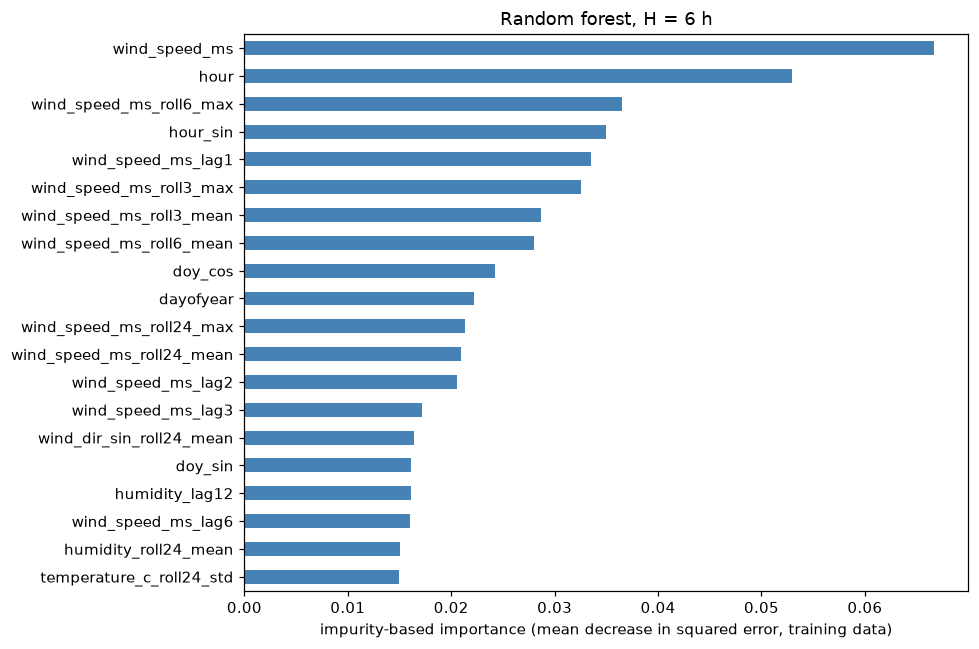

importance by feature family (share of total):
wind_speed_ms    37.3%
wind_dir         16.5%
humidity         13.8%
hour              9.6%
temperature_c     9.6%
pressure_hpa      6.1%
doy               4.0%
dayofyear         2.2%
month             0.0%


In [4]:
impurity = pd.Series(rf.feature_importances_, index=D['features']).sort_values(ascending=False)
print('top 20 features by impurity importance (H = {} h):'.format(H_MAIN))
print(impurity.head(20).round(4).to_string())
print()
print('sum of the top 10 shares: {:.1%} of the total importance'.format(impurity.head(10).sum()))

fig, ax = plt.subplots(figsize=(9, 6))
impurity.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('impurity-based importance (mean decrease in squared error, training data)')
ax.set_title('Random forest, H = {} h'.format(H_MAIN))
plt.tight_layout()
plt.show()

families = {k: sum(v for n, v in impurity.items() if n.startswith(k)) for k in
            ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir', 'hour', 'dayofyear', 'month', 'doy']}
print('importance by feature family (share of total):')
print(pd.Series(families).sort_values(ascending=False).apply(lambda v: '{:.1%}'.format(v)).to_string())

### 3.2 Permutation importance

Permutation importance answers a different and often more useful question: *if I randomly shuffle this column in the validation block, how much does the error get worse?*

- It is measured **on held-out data**, so it reflects generalisation.
- It has **no cardinality bias**.
- Its main weakness is the mirror image of the first: when features are **correlated**, shuffling one leaves the others intact, so the model can still recover the information and the shuffled column looks unimportant. Our 72 features contain many near-duplicates - expect this effect.

We measure it with `n_repeats=5` so we can report the spread across repeats, and with `n_jobs=1` so the notebook does not fight the rest of your machine for memory.

permutation importance computed in 13.9 s

top 15 features by permutation importance on the validation block:
                  feature  delta_MAE    std
                     hour     0.0519 0.0052
 wind_speed_ms_roll24_std     0.0230 0.0016
wind_speed_ms_roll24_mean     0.0175 0.0047
                 hour_sin     0.0152 0.0097
            wind_speed_ms     0.0146 0.0016
      temperature_c_lag24     0.0141 0.0007
 temperature_c_roll24_max     0.0128 0.0015
       wind_speed_ms_lag1     0.0107 0.0018
        pressure_hpa_lag3     0.0081 0.0007
  temperature_c_roll6_max     0.0079 0.0004
           humidity_lag24     0.0076 0.0006
  pressure_hpa_roll24_std     0.0075 0.0010
 wind_speed_ms_roll24_max     0.0072 0.0019
 wind_speed_ms_roll6_mean     0.0065 0.0012
     humidity_roll24_mean     0.0057 0.0017


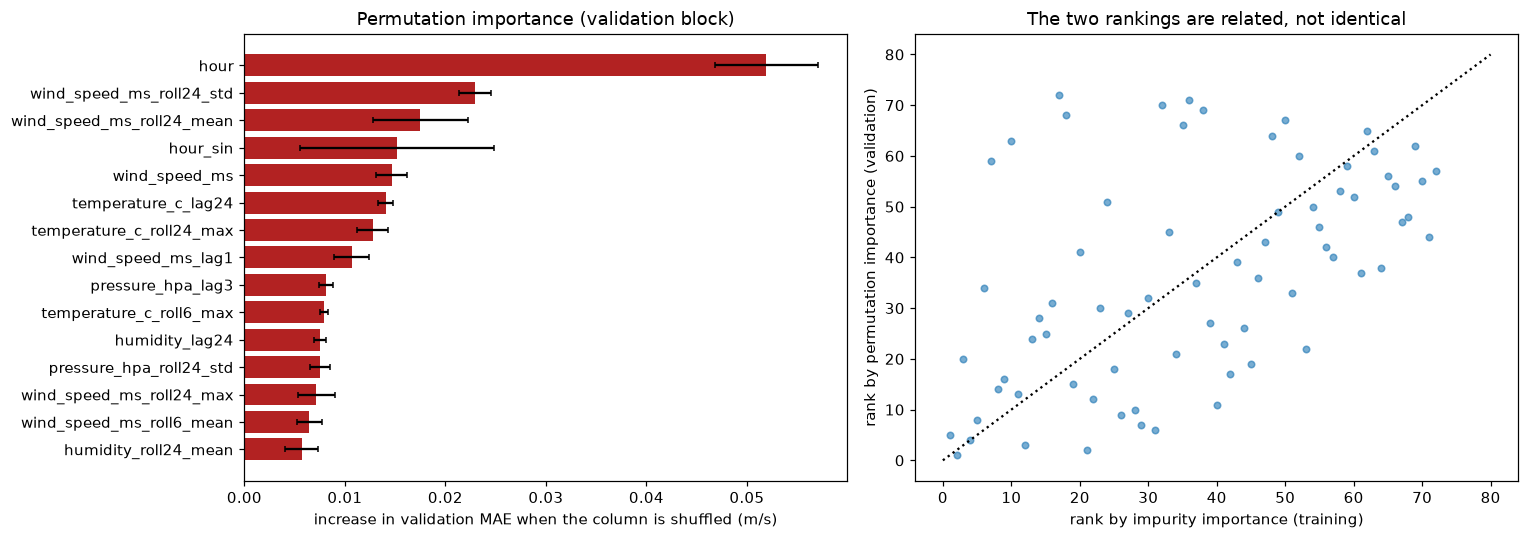

Interpretation:
  - the leading feature is the observed wind speed at the forecast origin (and
    its short lags): the model is mostly an inertia model with corrections;
  - a permutation delta of, say, 0.05 m/s means the column contributes a
    twentieth of a m/s - real, but small relative to a 1.3 m/s total error;
  - the widest error bars mark features whose role the model can replace with
    a correlated column, which is exactly the weakness described above.


In [5]:
from sklearn.inspection import permutation_importance

t0 = time.time()
perm = permutation_importance(rf, X_va, y_va, n_repeats=5, random_state=SEED,
                              scoring='neg_mean_absolute_error', n_jobs=1)
print('permutation importance computed in {:.1f} s'.format(time.time() - t0))

perm_mae = pd.DataFrame({'feature': D['features'],
                         'delta_MAE': perm.importances_mean,          # in m/s: increase in MAE when shuffled
                         'std': perm.importances_std}).sort_values('delta_MAE', ascending=False)
print()
print('top 15 features by permutation importance on the validation block:')
print(perm_mae.head(15).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = perm_mae.head(15)[::-1]
axes[0].barh(top['feature'], top['delta_MAE'], xerr=top['std'], color='firebrick', capsize=2)
axes[0].set_xlabel('increase in validation MAE when the column is shuffled (m/s)')
axes[0].set_title('Permutation importance (validation block)')

combined = pd.DataFrame({'impurity_rank': impurity.rank(ascending=False),
                         'permutation_rank': perm_mae.set_index('feature')['delta_MAE'].rank(ascending=False)})
axes[1].scatter(combined['impurity_rank'], combined['permutation_rank'], s=18, alpha=0.6)
axes[1].plot([0, 80], [0, 80], ls=':', color='black')
axes[1].set_xlabel('rank by impurity importance (training)')
axes[1].set_ylabel('rank by permutation importance (validation)')
axes[1].set_title('The two rankings are related, not identical')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  - the leading feature is the observed wind speed at the forecast origin (and')
print('    its short lags): the model is mostly an inertia model with corrections;')
print('  - a permutation delta of, say, 0.05 m/s means the column contributes a')
print('    twentieth of a m/s - real, but small relative to a 1.3 m/s total error;')
print('  - the widest error bars mark features whose role the model can replace with')
print('    a correlated column, which is exactly the weakness described above.')

### 3.3 Per-prediction explanation: SHAP (optional) or partial dependence

Impurity and permutation importance are *global*: one number per feature for the whole model. A **SHAP** value is *local*: for one specific hour, how much did each feature push the prediction up or down relative to the average prediction? That is what you need when you ask 'why did the model forecast a gale at 15:00 on 3 February?'.

SHAP is optional here. If it is unavailable, we use **partial dependence**, which is model-agnostic and answers a complementary question: *holding everything else as it is, how does the prediction change as this feature varies?* For wind speed that curve is physically meaningful and worth plotting in any case.

Both are descriptions of the model, not causal statements.


Partial dependence instead of SHAP
----------------------------------
partial dependence for: ['wind_speed_ms', 'wind_speed_ms_roll24_mean', 'hour_sin']


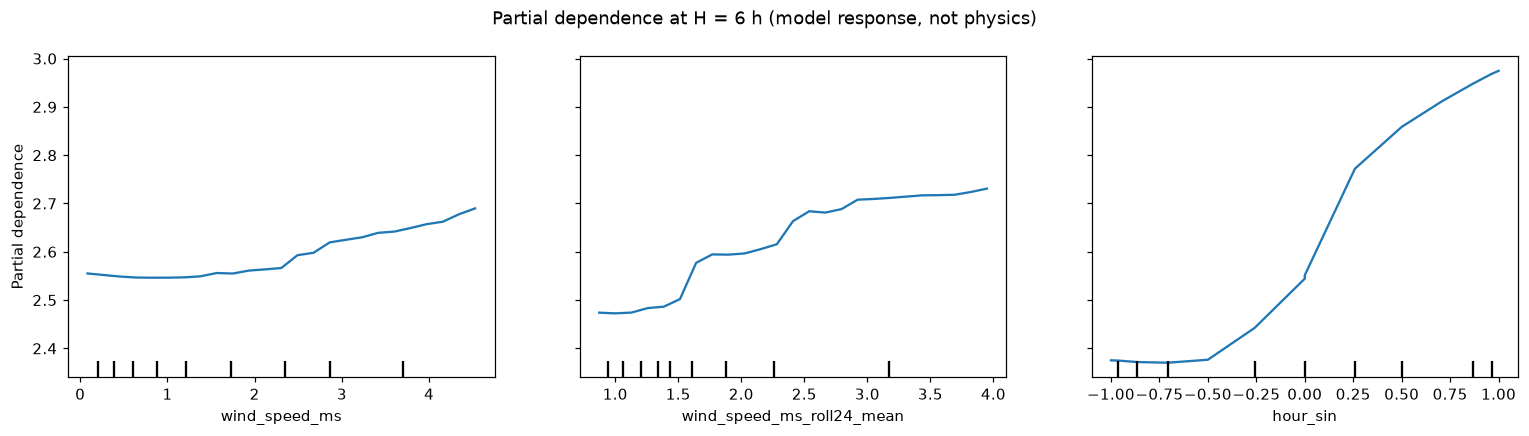

  wind_speed_ms                response from 2.150 to 3.111 m/s across the feature range (slope 0.216)
[info] the extra partial-dependence table was skipped: index 1 is out of bounds for axis 0 with size 1


In [6]:
SHAP_OK = False
if HAS_SHAP:
    try:
        explainer = shap.TreeExplainer(rf)
        X_explain = X_va.iloc[:400]                     # a subset keeps the figure readable
        try:
            shap_values = explainer.shap_values(X_explain)
        except Exception:
            shap_values = explainer(X_explain).values    # newer shap API
        vals = np.asarray(shap_values)
        if vals.ndim == 3:                                # some versions return (n, features, outputs)
            vals = vals[:, :, 0]
        shap.summary_plot(vals, X_explain, max_display=15, show=True)
        print('top features by mean |SHAP| (m/s), i.e. average magnitude of their push on a prediction:')
        print(pd.Series(np.abs(vals).mean(axis=0), index=X_explain.columns).sort_values(ascending=False).head(10).round(4).to_string())
        SHAP_OK = True
        del shap_values, vals
        gc.collect()
    except Exception as exc:
        print('shap could not run in this environment:', exc)
        print('the partial-dependence fallback is used instead')

if not SHAP_OK:
    print()
    print('Partial dependence instead of SHAP')
    print('----------------------------------')

from sklearn.inspection import partial_dependence, PartialDependenceDisplay

pdp_features = [c for c in ['wind_speed_ms', 'wind_speed_ms_roll24_mean', 'hour_sin', 'pressure_hpa'] if c in D['features']][:3]
print('partial dependence for:', pdp_features)
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(rf, X_va, pdp_features, kind='average',
                                        subsample=500, random_state=SEED, ax=ax,
                                        grid_resolution=25)
plt.suptitle('Partial dependence at H = {} h (model response, not physics)'.format(H_MAIN))
plt.tight_layout()
plt.show()

try:
    pdres = partial_dependence(rf, X_va, [D['features'].index(c) for c in pdp_features],
                               kind='average', grid_resolution=12)
    for k, name in enumerate(pdp_features):
        vals = np.array(pdres['average'][k]).ravel()
        grid = np.array(pdres['grid_values'][k])
        slope = (vals[-1] - vals[0]) / (grid[-1] - grid[0]) if grid[-1] != grid[0] else np.nan
        print('  {:<28s} response from {:.3f} to {:.3f} m/s across the feature range (slope {:.3f})'.format(
            name, vals[0], vals[-1], slope))
    print()
    print('A positive slope for wind_speed_ms means the model predicts stronger wind when')
    print('it is already windy - the inertia component. The curve is usually flatter at the')
    print('top end than the identity line, which is the quantitative signature of the')
    print('under-prediction of extremes discussed in the regime analysis below.')
except Exception as exc:
    print('[info] the extra partial-dependence table was skipped:', exc)

---

## 4. Residual analysis

A residual is `predicted - observed`, so **positive means the model over-forecast**. We ask four questions, each with a physical interpretation.

| Question | What a problem looks like | What it would mean |
|---|---|---|
| Is the residual centred on zero? | a persistent offset | systematic bias - e.g. the model learned a windier training season |
| Does the spread grow with wind speed? | a fan shape | errors are largest in the events that matter most (heteroscedasticity) |
| Are residuals autocorrelated? | slowly meandering residuals | the model has missed a physical process with its own memory (e.g. a synoptic cycle, the nocturnal jet) |
| Do errors cluster in time of day or season? | a diurnal or monthly pattern | the model has not captured the boundary-layer cycle |

### The pattern you are most likely to find at Abali

In our run the model shows a **positive mean bias** (it over-forecasts on average) *and* a **negative bias in the strong-wind bins** (it under-forecasts gales). Both are real, and they have different causes:

- the positive average bias is a **distribution shift**: the training block is spring and summer, which is windier on average than the autumn-winter validation block, so the model predicts a windier world than the one it is scored in;
- the negative bias at high wind speed is **regression to the mean**, compounded by the inability of trees to extrapolate beyond the training range.

Two consequences for your analysis:

1. **Do not 'fix' the average bias by subtracting it.** The offset was calibrated on one season and would double the error in another. If you want a de-biased forecast, calibrate the correction on the training period and then verify it on data the calibration never saw.
2. **Always report the bias per regime, not only the overall mean.** An overall bias of +0.9 m/s is not 'the model is 0.9 m/s too windy': it is 'the model is too windy in calm conditions and too calm in windy ones'. Only the second statement is something an operational user can act on.

residual summary (predicted - observed), H = 6 h, validation block:
  mean bias          : +0.8527 m/s
  median             : +1.0819 m/s
  std                : 1.4447 m/s
  MAE                : 1.3551 m/s
  RMSE               : 1.6770 m/s
  RMSE/MAE           : 1.238  (a heavy tail means a few large misses dominate)

bias by observed wind-speed bin (negative = the model under-forecasts):
             n    bias     MAE  persistence_MAE
speed_bin                                      
0-1        561  1.5837  1.5837           1.1802
1-2        266  1.0708  1.1293           1.1411
2-4        353  0.4329  0.8451           1.7347
4-8         90 -1.9817  2.0732           3.0356
>8           8 -7.2530  7.2530           7.4625


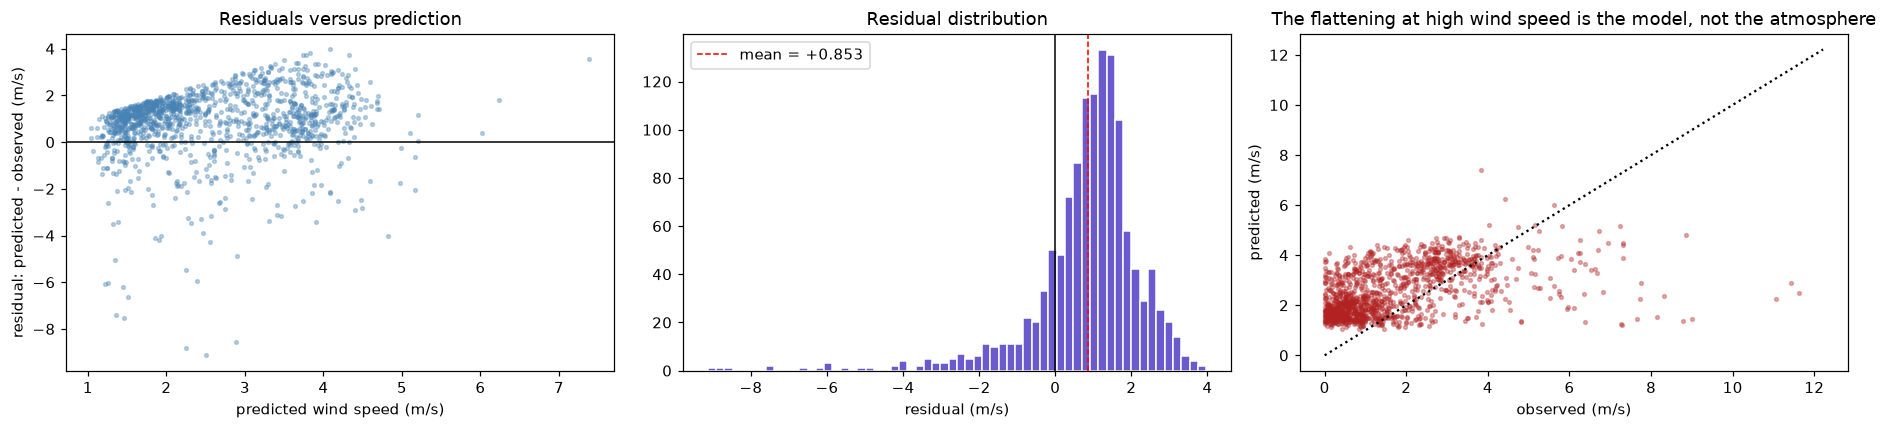


The third panel is the most scientifically important figure of this session:
the cloud bends below the 1:1 line for strong winds. A tree ensemble predicts
an average of training outcomes, so it can never exceed the largest value it saw
and it always regresses extreme events toward the mean. Report it as a known,
quantifiable limitation rather than as a rounding error.


In [7]:
print('residual summary (predicted - observed), H = {} h, validation block:'.format(H_MAIN))
print('  mean bias          : {:+.4f} m/s'.format(ERR['residual'].mean()))
print('  median             : {:+.4f} m/s'.format(ERR['residual'].median()))
print('  std                : {:.4f} m/s'.format(ERR['residual'].std()))
print('  MAE                : {:.4f} m/s'.format(ERR['abs_error'].mean()))
print('  RMSE               : {:.4f} m/s'.format(np.sqrt((ERR['residual'] ** 2).mean())))
print('  RMSE/MAE           : {:.3f}  (a heavy tail means a few large misses dominate)'.format(
    np.sqrt((ERR['residual'] ** 2).mean()) / ERR['abs_error'].mean()))
print()
print('bias by observed wind-speed bin (negative = the model under-forecasts):')
bins = [0, 1, 2, 4, 8, 100]
labels = ['0-1', '1-2', '2-4', '4-8', '>8']
ERR['speed_bin'] = pd.cut(ERR['observed'], bins=bins, labels=labels, right=False)
by_bin = ERR.groupby('speed_bin', observed=True).agg(n=('residual', 'size'), bias=('residual', 'mean'),
                                                     MAE=('abs_error', 'mean'),
                                                     persistence_MAE=('persistence_error', 'mean'))
print(by_bin.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].scatter(ERR['predicted'], ERR['residual'], s=6, alpha=0.35, color='steelblue')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_xlabel('predicted wind speed (m/s)')
axes[0].set_ylabel('residual: predicted - observed (m/s)')
axes[0].set_title('Residuals versus prediction')

axes[1].hist(ERR['residual'].dropna(), bins=60, color='slateblue', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(ERR['residual'].mean(), color='red', lw=1, ls='--', label='mean = {:+.3f}'.format(ERR['residual'].mean()))
axes[1].set_xlabel('residual (m/s)')
axes[1].set_title('Residual distribution')
axes[1].legend()

axes[2].scatter(ERR['observed'], ERR['predicted'], s=6, alpha=0.35, color='firebrick')
lim = [0, max(ERR['observed'].max(), ERR['predicted'].max()) * 1.05]
axes[2].plot(lim, lim, ls=':', color='black')
axes[2].set_xlabel('observed (m/s)')
axes[2].set_ylabel('predicted (m/s)')
axes[2].set_title('The flattening at high wind speed is the model, not the atmosphere')
plt.tight_layout()
plt.show()

print()
print('The third panel is the most scientifically important figure of this session:')
print('the cloud bends below the 1:1 line for strong winds. A tree ensemble predicts')
print('an average of training outcomes, so it can never exceed the largest value it saw')
print('and it always regresses extreme events toward the mean. Report it as a known,')
print('quantifiable limitation rather than as a rounding error.')

In [8]:
# Residual autocorrelation: does the model leave structure behind?
lags = [1, 2, 3, 6, 12, 24]
acf_res = pd.Series({k: ERR['residual'].autocorr(lag=k) for k in lags})
acf_obs = pd.Series({k: ERR['observed'].autocorr(lag=k) for k in lags})
print('autocorrelation of the residual, versus that of the observations:')
print(pd.DataFrame({'residual_ACF': acf_res, 'observed_ACF': acf_obs}).round(3).to_string())
print()
print('Residuals with a positive autocorrelation at 1-6 h mean the errors come in runs:')
print('the model misses a process that itself persists. Persistence-style structure left')
print('in the residuals is a signal that an additional predictor - typically a synoptic')
print('variable such as a large-scale pressure gradient or an NWP wind speed - could')
print('still add skill. That is a modelling opportunity, not a curiosity.')

autocorrelation of the residual, versus that of the observations:
    residual_ACF  observed_ACF
1          0.755         0.820
2          0.532         0.645
3          0.372         0.500
6          0.073         0.185
12        -0.136        -0.046
24         0.086         0.285

Residuals with a positive autocorrelation at 1-6 h mean the errors come in runs:
the model misses a process that itself persists. Persistence-style structure left
in the residuals is a signal that an additional predictor - typically a synoptic
variable such as a large-scale pressure gradient or an NWP wind speed - could
still add skill. That is a modelling opportunity, not a curiosity.


---

## 5. Error by regime: diurnal, seasonal and by wind speed

The average MAE is a single number that hides the physics. Three breakdowns are essential.

### 5.1 The diurnal cycle of error

At a mountain station the error typically peaks in the middle of the day, when convective mixing makes the wind speed genuinely less predictable, and is smaller at night when a stable boundary layer decouples the surface from the flow aloft and the wind changes slowly. If your data show the opposite, that is a result worth reporting - the specific behaviour of the Abali valley is an empirical question.

### 5.2 By season and by month

Errors follow the seasonal cycle of the wind regime. Because our validation block is autumn/winter, this breakdown is also the honest way to present the seasonal drift we identified in Session 2.

### 5.3 By wind-speed regime - the most important one

A forecast that is excellent for 2 m/s and useless for 12 m/s is not one product: it is two. Split the error into calm, light, moderate and strong hours, and compare the model with persistence inside each bin. This is where the operational conclusion comes from.

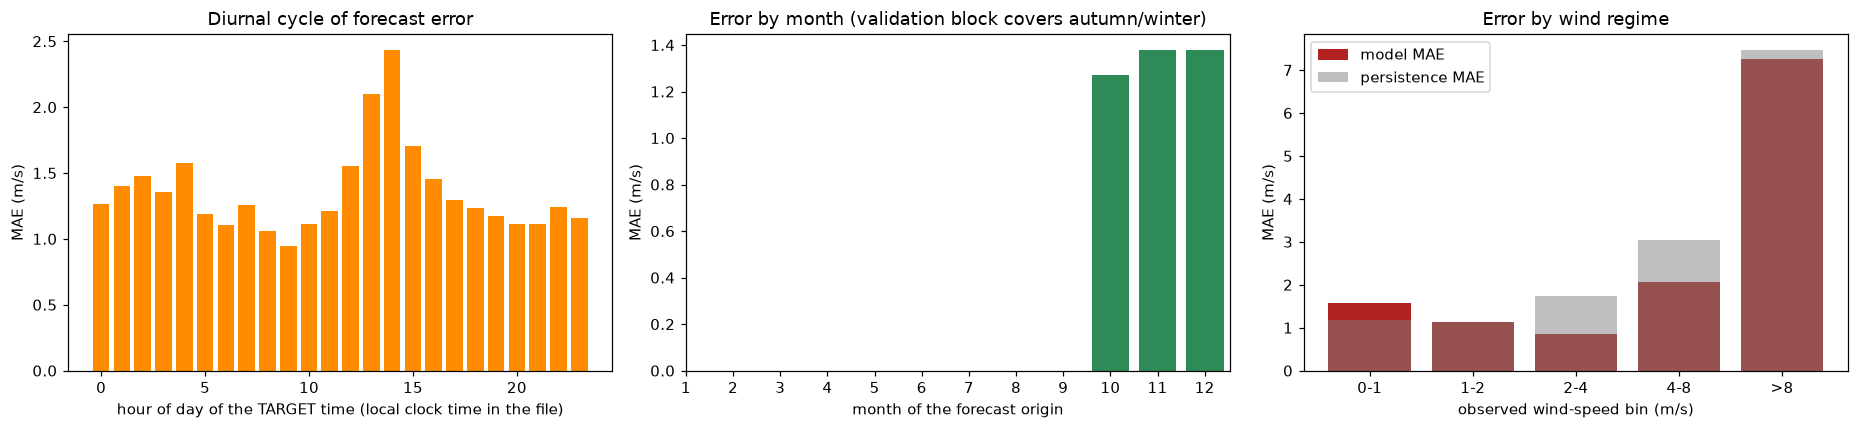

DIURNAL BREAKDOWN:
             n    MAE   bias  observed_mean
valid_hour                                 
0           56  1.261  0.673          1.182
1           55  1.401  0.324          1.492
2           54  1.476  0.162          1.618
3           54  1.358  0.306          1.503
4           53  1.578  0.244          1.587
5           52  1.185  0.200          1.769
6           51  1.105  0.646          2.205
7           50  1.256  1.078          2.316
8           51  1.059  0.769          2.768
9           52  0.942  0.782          3.017
10          53  1.115  0.731          3.131
11          53  1.211  1.068          2.902
12          53  1.556  1.330          2.617
13          52  2.099  1.870          1.946
14          53  2.432  2.084          1.258
15          53  1.704  1.113          1.337
16          54  1.453  0.869          1.329
17          54  1.298  0.764          1.266
18          53  1.232  1.023          1.022
19          53  1.175  0.960          1.063
20          5

In [9]:
by_hour = ERR.groupby('valid_hour').agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'),
                                        bias=('residual', 'mean'), observed_mean=('observed', 'mean'))
by_month = ERR.groupby('month').agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'),
                                    bias=('residual', 'mean'), observed_mean=('observed', 'mean'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar(by_hour.index, by_hour['MAE'], color='darkorange')
axes[0].set_xlabel('hour of day of the TARGET time (local clock time in the file)')
axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('Diurnal cycle of forecast error')
axes[1].bar(by_month.index, by_month['MAE'], color='seagreen')
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('month of the forecast origin')
axes[1].set_ylabel('MAE (m/s)')
axes[1].set_title('Error by month (validation block covers autumn/winter)')
axes[2].bar(by_bin.index.astype(str), by_bin['MAE'], color='firebrick', label='model MAE')
axes[2].bar(by_bin.index.astype(str), by_bin['persistence_MAE'], color='grey', alpha=0.5, label='persistence MAE')
axes[2].set_xlabel('observed wind-speed bin (m/s)')
axes[2].set_ylabel('MAE (m/s)')
axes[2].set_title('Error by wind regime')
axes[2].legend()
plt.tight_layout()
plt.show()

print('diurnal breakdown:'.upper())
print(by_hour.round(3).to_string())
print()
print('seasonal breakdown:')
print(by_month.round(3).to_string())
print()
print('regime breakdown (bias < 0 = under-forecast):')
print(by_bin.round(3).to_string())

In [10]:
# The same regime analysis at every horizon: does the failure mode persist?
rows = []
for H in HORIZONS:
    Dh = DATA[H]
    model = RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt', min_samples_leaf=2,
                                  random_state=SEED, n_jobs=N_JOBS)
    model.fit(Dh['X_train'], Dh['y_train'])
    pred = model.predict(Dh['X_val'])
    del model
    tmp = pd.DataFrame({'observed': Dh['y_val'].values, 'predicted': pred,
                        'persistence': Dh['X_val']['wind_speed_ms'].values})
    tmp['abs_error'] = (tmp['predicted'] - tmp['observed']).abs()
    tmp['bias'] = tmp['predicted'] - tmp['observed']
    tmp['persistence_error'] = (tmp['persistence'] - tmp['observed']).abs()
    tmp['regime'] = pd.cut(tmp['observed'], bins=bins, labels=labels, right=False)
    g = tmp.groupby('regime', observed=True).agg(n=('abs_error', 'size'), MAE=('abs_error', 'mean'),
                                                 bias=('bias', 'mean'), persistence_MAE=('persistence_error', 'mean'))
    g['horizon_h'] = H
    rows.append(g.reset_index())
    gc.collect()

REGIME = pd.concat(rows, ignore_index=True)
print('MAE by wind regime and horizon:')
print(REGIME.pivot(index='regime', columns='horizon_h', values='MAE').round(3).to_string())
print()
print('mean bias by wind regime and horizon (negative = under-forecast):')
print(REGIME.pivot(index='regime', columns='horizon_h', values='bias').round(3).to_string())
print()
print('number of hours per regime (same for all horizons, up to edge effects):')
print(REGIME.pivot(index='regime', columns='horizon_h', values='n').to_string())
print()
print('This table is the operational summary of the model. Read it as a grid of')
print('questions: for the regime and horizon I care about, is the model better than')
print('persistence, and how large is the systematic bias?')

MAE by wind regime and horizon:
horizon_h     3      6      12     24
regime                               
0-1        1.104  1.584  1.514  1.516
1-2        0.694  1.129  0.934  0.856
2-4        0.654  0.845  0.653  0.676
4-8        2.089  2.073  2.583  2.760
>8         7.051  7.253  7.413  9.827

mean bias by wind regime and horizon (negative = under-forecast):
horizon_h     3      6      12     24
regime                               
0-1        1.103  1.584  1.514  1.516
1-2        0.557  1.071  0.885  0.766
2-4       -0.014  0.433  0.138  0.063
4-8       -1.977 -1.982 -2.564 -2.755
>8        -7.051 -7.253 -7.413 -9.827

number of hours per regime (same for all horizons, up to edge effects):
horizon_h   3    6    12   24
regime                       
0-1        565  561  556  543
1-2        264  266  262  249
2-4        356  353  347  338
4-8         93   90   85   77
>8           8    8   13   27

This table is the operational summary of the model. Read it as a grid of
questions: f

---

## 6. Writing the scientific interpretation

You now have everything needed for the discussion section of a report. A template that works:

1. **What the model relies on.** *At 6 h the model is dominated by the observed wind speed and its short lags; pressure, temperature, humidity and direction contribute little at the margins.* Support it with the two importance rankings.
2. **Where it works.** *Skill versus persistence is positive at 3-6 h...* (use the numbers).
3. **Where it fails, and why.** Three mechanisms, all demonstrated above:
   - **regression to the mean** at high wind speeds (trees cannot extrapolate);
   - **no synoptic information**: the predictors are all local surface variables, so a frontal passage that has not yet started at the station is invisible;
   - **seasonal drift**: the validation block is a different season from the training block, and part of the measured error is that shift rather than model error.
4. **What would improve it.** In order of expected value:
   - add a large-scale predictor (reanalysis wind speed or pressure gradient at the station) - it directly addresses mechanisms 2 and 3;
   - model the *distribution* rather than the mean (quantile regression or probabilistic forecasting), since the error is heteroscedastic;
   - verify on a full year (rolling-origin over 12 months) instead of one season;
   - for extreme events, use a dedicated classifier-plus-regressor approach rather than one regression for all regimes.
5. **Limitations.** One year of data, one station, no NWP inputs, hourly resolution, deterministic output.

**Check for understanding:** a reviewer asks why your 24 h model has a positive skill against persistence but a negative R2. What is the correct answer? *R2 compares the model with the mean of the validation block, while the skill score compares it with persistence on the same rows. They can disagree because persistence and the block mean are different references, and because the block has a trend or a shifted distribution. Report both, and explain which reference is meaningful for your application.*

---

## 7. Part B - the professional use of AI and LLMs

You will use an LLM in your scientific work. The question is not *whether* but *how*, and the standard is the same as for a human collaborator: their output must be checkable, and **you** are accountable for the final claim.

### 7.1 A working mental model

| The LLM is good at | The LLM is unreliable at |
|---|---|
| boilerplate (plots, loops, file handling) | whether your split leaks future information |
| translating between libraries | whether your metric answers your scientific question |
| explaining a concept at three levels of detail | units, magnitudes and physical plausibility |
| rewriting code for clarity | knowing that *your* station has a winter regime change |
| producing a first draft of a methods section | knowing what is in your data |

The division of labour: **the LLM supplies fluency, you supply correctness.**

### 7.2 Prompts that produce usable science code

```
Context: hourly meteorological station data, 10,400 rows, forecast horizon 6 h.
Task: write a function that returns MAE, RMSE, MSE and R2 for two 1-D arrays.
Constraints: scikit-learn 1.x; no version-dependent arguments; every metric in m/s
except R2; docstring states when R2 is meaningless; no file I/O.
Then: list three ways this function could be misused in a time-series evaluation.
```

Four ingredients make the difference: **context** (what the data are), **task**, **constraints** (versions, units, boundaries), and a **critique request** that forces the model to consider misuse.

### 7.3 Prompts for review, not for generation

Generation is the least valuable use of an LLM in science. Review is the most valuable:

```
Act as a reviewer for a geoscience journal. Here is my feature-engineering function.
For every line: (a) prove that it uses only information available at the forecast origin,
(b) flag any statistical problem (circular variables, sentinel values, gap handling),
(c) flag any irreproducible element (seeds, paths, hidden state).
Output a table: line | issue | severity (low/med/high) | minimal fix.
Do not rewrite the function.
```

### 7.4 Debugging with an LLM

```
Expected: validation MAE about 1.5 m/s.
Observed: 0.02 m/s, and the residual plot is a flat line at zero.
Code: <paste only the evaluation function>
Data: <paste 5 rows, dtypes, and the split description>
Environment: Python 3.13, sklearn 1.7, pandas 2.3.
Give the three most likely causes in order, then the single fastest check for each.
Do not suggest a different model.
```

A near-zero error is a *bug report*, not a success. The four usual causes, in order of frequency: the target leaked into the features; the split is shuffled; the prediction array is aligned to the wrong rows; a scaled target was compared with unscaled observations.

### 7.5 Hallucination checklist

| Failure mode | How it looks | How to catch it deterministically |
|---|---|---|
| invented API | `df.resample_hourly()` - plausible, non-existent | run it; or `?pd.DataFrame.resample` in the notebook |
| wrong default | 'rolling drops NaN by default' | check the docstring; print a small example |
| template leakage | `train_test_split(..., shuffle=True)` | read every split line by hand |
| plausible statistics | 'z scores above 3 should be removed' | compute how many rows that removes and what they are |
| confident physics | a confident mechanism that is wrong | check against a textbook or a colleague |
| version drift | code that only runs on the version it was trained on | run it in your environment, and pin versions in the report |

### 7.6 The boundary between assistance and blind copying

A practical rule with three questions:

1. **Can I explain this line to a colleague?** If not, do not keep it.
2. **Can I test it?** Every generated function needs a check with a known answer. For a metric, that can be two numbers; for a split, that can be a printed date range.
3. **Would I defend it in review?** If the honest answer is 'the model wrote it', rewrite it until the answer is 'because the data require it'.

Blind copying has a specific signature in student work: elegant code, no tests, an unexplained high score, and a methods section that cannot say why a parameter has the value it has.

### 7.7 Documenting AI use

Most journals now expect a statement. A usable one:

> 'An LLM assistant was used to draft plotting boilerplate and to review the feature-engineering code for leakage. All generated code was executed, unit-checked against hand-computed values and reviewed by the authors, who take responsibility for the analysis. No AI tool was used to generate scientific results or interpretations.'

### 7.8 Worked exercise: find the leak

The function below was 'written by an assistant' and looks reasonable. It is not. Find every problem before reading the answer.

```python
def make_features(df, horizon=6):
    df = df.copy()
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    df['ws_mean_24h'] = df['wind_speed_ms'].rolling(24, center=True).mean()
    df['ws_lag1'] = df['wind_speed_ms'].shift(1)
    df['dir_sin'] = np.sin(np.radians(df['wind_direction_deg']))
    df['dir_cos'] = np.cos(np.radians(df['wind_direction_deg']))
    df['pressure_filled'] = df['pressure_hpa'].interpolate(limit_direction='both')
    df['hour'] = df.index.hour
    df = df.dropna()
    X = df.drop(columns=['target'])
    y = df['target']
    return X, y

X, y = make_features(hourly)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=False)
scaler = StandardScaler().fit(X)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)
```

The defects, in order of severity:

1. **Centred rolling window.** `rolling(24, center=True)` puts 12 *future* hours into a feature. This is the classic temporal leak and the worst offender here.
2. **Backward interpolation.** `interpolate(limit_direction='both')` fills gaps using later observations.
3. **Scaler fitted on everything.** `StandardScaler().fit(X)` sees the test rows, before the split.
4. **Silent `dropna()` after the target shift.** It removes the last `horizon` rows (correct) but also silently discards every row touched by a rolling window, and it does so *after* the target was created - so the row count no longer matches the intent.
5. **`shuffle=False` without a purge gap.** Better than shuffling, but the last training target still falls inside the test window.
6. **No cyclical encoding for the hour**, and a raw `hour` integer that imposes a false jump between 23 and 0.

Run the honest version (our `build_horizon_dataset`) and the leaky version side by side, and record the difference in validation MAE. That difference is the price of leakage, and it is the single most persuasive thing you can show a student who doubts the rules.

---

## 8. Common pitfalls

**Pitfall 1 - reading importance as causality.**  
'The model relies on wind direction' is defensible. 'Wind direction controls the wind speed' is a physical claim needing physical evidence.

**Pitfall 2 - permuting on the training set.**  
Permutation importance must be computed on held-out data, or it measures memorisation.

**Pitfall 3 - comparing importances across differently-sized feature sets.**  
Adding features changes every importance value. Compare rankings within one model, not across models.

**Pitfall 4 - interpreting correlated features separately.**  
With 72 features and near-duplicates, a low permutation importance can simply mean 'the information is available elsewhere'.

**Pitfall 5 - trusting SHAP as a physical explanation.**  
SHAP explains the model's output decomposition. It is not an attribution of the physical wind.

**Pitfall 6 - analysing residuals only in aggregate.**  
The mean bias can be zero while the model is +1 m/s in the afternoon and -1 m/s at night. Always look at the diurnal and regime breakdowns.

**Pitfall 7 - reporting a score without its dispersion.**  
Residual autocorrelation means hourly errors are not independent, so the effective sample size is much smaller than the row count.

**Pitfall 8 - accepting a confident AI answer because the code runs.**  
Running code is necessary and not sufficient: the leaky example above runs perfectly.

**Pitfall 9 - letting the assistant define the experiment.**  
The question, the split and the metric are your responsibility. The LLM does not know your science.

---

## 9. Exercises

### Level 1 - understanding

1. State the two biases of impurity-based importance.
2. Why must permutation importance be computed on held-out data?
3. What does a positive residual mean in our convention, and what does a positive *mean* residual imply?
4. Explain in one sentence why a tree model's predictions flatten at high wind speed.

### Level 2 - implementation

5. Compute permutation importance with `n_repeats=20` and compare the ranking and the error bars with the 5-repeat version. Which features change rank?
6. Compute importance separately for the training and validation blocks and identify the features whose importance collapses - those are the memorised ones.
7. Add a 'wind direction sector' error analysis (8 sectors from `wind_dir_sin`/`wind_dir_cos` using `arctan2`) and report the MAE per sector.
8. Fit a boosting model and repeat the three importance analyses. Do the ensembles agree on the leading features?
9. Install SHAP if it is missing and reproduce the summary plot; then compare the SHAP ranking with the permutation ranking.

### Level 3 - reasoning

10. The residuals show a positive autocorrelation at 6-24 h. Propose two physical predictors that could remove it, and explain how you would evaluate the improvement without touching the test block.
11. Your model has a near-zero mean bias but a MAE that is 60 % larger in the afternoon than at night. Explain how both can be true and what it implies for the users of the forecast.
12. A colleague reports that the model 'captures the storm of 3 February well'. Write the two checks you would run before repeating that claim.
13. You are asked to forecast a 25 m/s event at a station whose record maximum is 18 m/s. Explain precisely why your model cannot do it, and describe a defensible alternative approach.

### Level 4 - application (project work)

14. **Write the discussion section.** Using your own output: what the model learned, where it works, three failure mechanisms with evidence, and a prioritised improvement plan.
15. **Write the AI-use statement for your project.** List every place an assistant contributed, what you verified and how. This is now a standard requirement in most journals, and writing it honestly is a professional skill in itself.
16. **Audit a colleague's notebook with an assistant.** Take the flawed function in 7.8, ask an LLM to review it, and compare its list of defects with yours. Report which defects it missed - that gap defines the part of the job that remains yours.

---

## 10. Reproducibility notes

- **One source:** `data/raw/abali.xlsx`, cleaned in memory, nothing written to disk.
- **Seeds:** `SEED = 42` for the forest, the permutation shuffling and the partial-dependence subsample. Permutation importance also depends on `n_repeats`: report it.
- **Interpretation is model-specific.** Every statement in this notebook refers to the fitted model at `H = 6 h` with `N_TREES = {}` trees, unless stated otherwise. Record the hyper-parameters next to the interpretation.
- **Optional dependency:** SHAP. If it is absent, the notebook falls back to partial dependence and says so; if you install it, record the version.
- **The test block is still untouched.** Sessions 1-6 never score it.

---

## 11. Key takeaways

1. Impurity importance is measured on training data and biased toward high-cardinality features; permutation importance is measured on held-out data but distracted by correlated features. Use both, and state their limits.
2. SHAP explains one prediction; partial dependence shows the average model response. Neither is a physical attribution.
3. The model is largely an inertia model: the observed wind speed and its short lags dominate, with the diurnal cycle as the correcting signal at longer horizons.
4. Residuals are heteroscedastic and flatten at high wind speed: trees cannot extrapolate, so extreme events are systematically under-forecast.
5. Error varies with time of day, season and wind regime; a single MAE hides the physics that a reader needs.
6. LLMs are excellent for review, boilerplate and explanation, and unreliable for leakage, units and physical plausibility. Verify with checks that have known answers, and document your use.

In [11]:
# ===========================================================================
# FINAL VALIDATION CELL - run last, in every notebook
# ===========================================================================
WARNINGS = []
if not HAS_SHAP:
    WARNINGS.append('shap not installed: per-prediction explanations replaced by partial dependence')
if not HAS_LGBM:
    WARNINGS.append('lightgbm not installed')
if not HAS_XGB:
    WARNINGS.append('xgboost not installed')
if QUICK_MODE:
    WARNINGS.append('QUICK_MODE=True: {} trees, 5 permutation repeats'.format(N_TREES))
WARNINGS.append('feature importance explains the fitted model, not the atmosphere')
WARNINGS.append('interpretation applies to H = {} h with {} trees; other horizons were checked separately'.format(H_MAIN, N_TREES))

manifest = {
    'notebook': '06_model_interpretation_and_ai_assisted_workflow_abali.ipynb',
    'session': 'Session 6 - model interpretation and professional AI-assisted workflow',
    'dataset_used': RAW_PATH + ' (Abali station, hourly, cleaned in memory)',
    'target_variable': 'wind_speed_ms at T + H (m/s)',
    'forecast_horizons_hours': HORIZONS,
    'analysed_horizon_h': H_MAIN,
    'models_used': ['Random Forest (interpreted at H = {} h)'.format(H_MAIN)],
    'metrics_used': ['MAE', 'RMSE', 'R2', 'bias (mean residual)', 'residual ACF', 'error by diurnal cycle, month and wind regime'],
    'interpretation_methods': ['impurity feature importance (training)',
                               'permutation importance (validation, 5 repeats)',
                               'SHAP (if installed)' if HAS_SHAP else 'SHAP unavailable -> partial dependence used',
                               'partial dependence',
                               'residual diagnostics'],
    'top_features_permutation': perm_mae.head(10)['feature'].tolist(),
    'validation_MAE_model': float(metrics(y_va, rpred)['MAE']),
    'validation_MAE_persistence': float(metrics(y_va, pers)['MAE']),
    'mean_bias': float(ERR['residual'].mean()),
    'error_by_regime_MAE': {str(k): float(v) for k, v in REGIME[REGIME['horizon_h'] == H_MAIN].set_index('regime')['MAE'].items()},
    'ai_workflow_checks': ['run every generated snippet', 'verify the API exists in the docstring',
                           'read every split and shift line by hand',
                           'check physical plausibility of numbers and units',
                           'require a known-answer test for generated functions',
                           'document AI use in the report'],
    'test_block_touched': False,
    'files_written': 'none (all work in memory)',
    'random_seed': SEED,
    'warnings': WARNINGS,
}
print(json.dumps(manifest, indent=2, default=str))

{
  "notebook": "06_model_interpretation_and_ai_assisted_workflow_abali.ipynb",
  "session": "Session 6 - model interpretation and professional AI-assisted workflow",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, hourly, cleaned in memory)",
  "target_variable": "wind_speed_ms at T + H (m/s)",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "analysed_horizon_h": 6,
  "models_used": [
    "Random Forest (interpreted at H = 6 h)"
  ],
  "metrics_used": [
    "MAE",
    "RMSE",
    "R2",
    "bias (mean residual)",
    "residual ACF",
    "error by diurnal cycle, month and wind regime"
  ],
  "interpretation_methods": [
    "impurity feature importance (training)",
    "permutation importance (validation, 5 repeats)",
    "SHAP unavailable -> partial dependence used",
    "partial dependence",
    "residual diagnostics"
  ],
  "top_features_permutation": [
    "hour",
    "wind_speed_ms_roll24_std",
    "wind_speed_ms_roll24_mean",
    "hour_sin",
    "wi

---

### What comes next

In **Session 7** everything is assembled into one pipeline and one report:

- the full route from raw Excel to a verified forecast, in a single reusable script;
- the choice of the final model per horizon, justified by validation evidence;
- **one** evaluation on the untouched test block, with baselines in the same table;
- the figures a geoscience reader expects, and the limitations they must be told about;
- the structure of a report, a reproducibility package and a one-slide summary.

Before then, finish exercises 5, 11 and 14 - exercise 14 is the discussion section of your report.